**GEREKLİ KURULUMLAR**

In [ ]:
!pip install xgboost lightgbm catboost optuna textstat -q
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
import textstat
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Embedding, Conv1D, MaxPooling1D, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
import os
import pickle
import json
from datetime import datetime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 33.5 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
data_path = '/content/drive/MyDrive/tez_dataset.csv'
df = pd.read_csv(data_path)
print(f" Yüklendi: {len(df)} satır, {len(df.columns)} kolon")
print(f"  Kolonlar: {df.columns.tolist()}")
if 'text' not in df.columns:
    print("\n HATA: 'text' kolonu bulunamadı")
else:
    print("\n 'text' kolonu bulundu")
    print(f"  Ortalama metin uzunluğu: {df['text'].str.len().mean():.0f} karakter")


 Yüklendi: 534 satır, 3 kolon
  Kolonlar: ['text', 'label', 'filename']

 'text' kolonu bulundu
  Ortalama metin uzunluğu: 162149 karakter


**ÖZELLİK ÇIKARIMI - KARMAŞIKLIK İNDEKSİ**


 Özellikler çıkarılıyor


Feature extraction: 100%|██████████| 534/534 [01:43<00:00,  5.14it/s]


7 özellik eklendi

 HEDEF DEĞİŞKEN İSTATİSTİKLERİ:
  Ortalama: 14.13
  Std Dev:  2.39
  Min:      7.27
  Max:      25.00


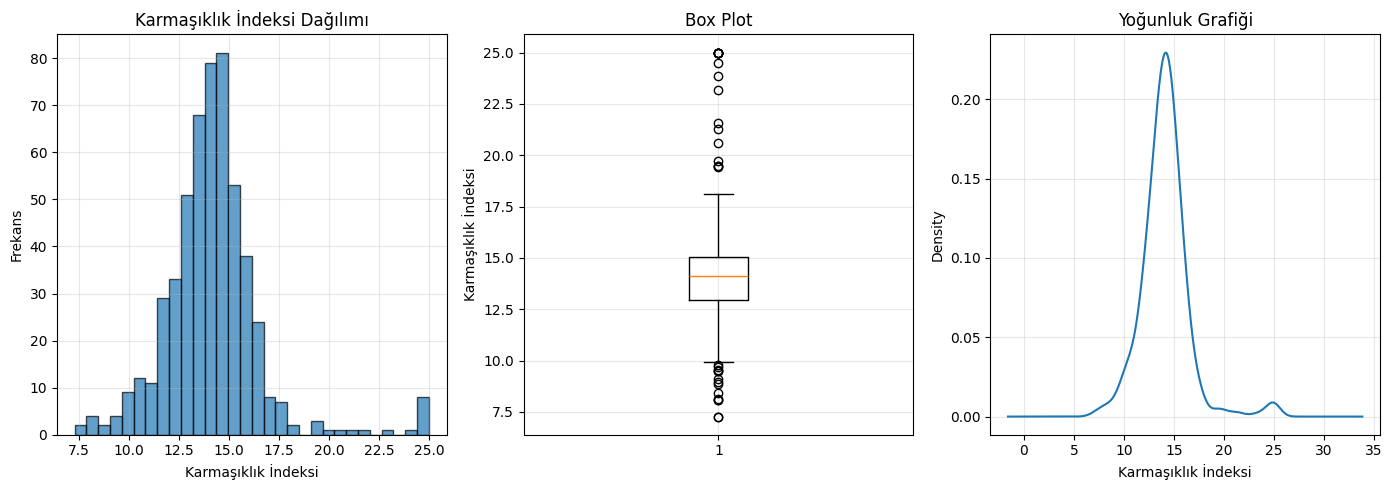

In [ ]:
class TextFeatureExtractor:
    def __init__(self):
        self.academic_connectors = [
            'dolayısıyla', 'sonuç olarak', 'bu nedenle', 'bu sebeple',
            'öte yandan', 'buna karşın', 'ancak', 'fakat',
            'örneğin', 'mesela', 'nitekim',
            'ayrıca', 'bununla birlikte', 'üstelik'
        ]

    def calculate_readability(self, text):
        try:
            flesch = 100 - textstat.flesch_reading_ease(text)
            return max(0, min(100, flesch))
        except:
            return 50

    def calculate_sentence_complexity(self, text):
        try:
            sentences = sent_tokenize(text)
            if len(sentences) == 0:
                return 0
            words_per_sentence = [len(word_tokenize(sent)) for sent in sentences]
            avg_length = np.mean(words_per_sentence)
            normalized = min(100, (avg_length - 10) * 2.5)
            return max(0, normalized)
        except:
            return 0

    def calculate_lexical_diversity(self, text):
        try:
            words = word_tokenize(text.lower())
            words = [w for w in words if w.isalnum()]
            if len(words) == 0:
                return 0
            ttr = len(set(words)) / len(words)
            return ttr * 100
        except:
            return 0

    def calculate_technical_density(self, text):
        try:
            words = word_tokenize(text.lower())
            words = [w for w in words if w.isalnum()]
            if len(words) == 0:
                return 0
            long_words = [w for w in words if len(w) > 8]
            density = (len(long_words) / len(words)) * 100
            return min(100, density * 5)
        except:
            return 0

    def calculate_passive_ratio(self, text):
        try:
            passive_markers = ['edilmiştir', 'edilmektedir', 'olunmuştur',
                             'yapılmıştır', 'yapılmaktadır', 'incelenmiştir']
            sentences = sent_tokenize(text)
            if len(sentences) == 0:
                return 0
            passive_count = sum(1 for sent in sentences
                              if any(marker in sent.lower() for marker in passive_markers))
            return (passive_count / len(sentences)) * 100
        except:
            return 0

    def calculate_connector_density(self, text):
        try:
            words = word_tokenize(text.lower())
            if len(words) == 0:
                return 0
            connector_count = sum(1 for conn in self.academic_connectors
                                if conn in text.lower())
            density = (connector_count / len(words)) * 1000
            return min(100, density * 2)
        except:
            return 0

    def calculate_complexity_index(self, text):
        readability = self.calculate_readability(text)
        sentence_complex = self.calculate_sentence_complexity(text)
        lexical_div = self.calculate_lexical_diversity(text)
        tech_density = self.calculate_technical_density(text)
        passive_ratio = self.calculate_passive_ratio(text)
        connector_density = self.calculate_connector_density(text)
        complexity_index = (
            0.25 * readability +
            0.20 * sentence_complex +
            0.15 * lexical_div +
            0.20 * tech_density +
            0.10 * passive_ratio +
            0.10 * connector_density
        )

        return {
            'complexity_index': complexity_index,
            'readability_score': readability,
            'sentence_complexity': sentence_complex,
            'lexical_diversity': lexical_div,
            'technical_density': tech_density,
            'passive_ratio': passive_ratio,
            'connector_density': connector_density
        }

    def extract_all_features(self, df, text_column='text'):
        print("\n Özellikler çıkarılıyor")
        results = []
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Feature extraction"):
            text = str(row[text_column])
            features = self.calculate_complexity_index(text)
            results.append(features)
        feature_df = pd.DataFrame(results)
        df = pd.concat([df, feature_df], axis=1)
        print(f"{len(feature_df.columns)} özellik eklendi")
        return df

extractor = TextFeatureExtractor()
df = extractor.extract_all_features(df, text_column='text')
target = 'complexity_index'

print(f"\n HEDEF DEĞİŞKEN İSTATİSTİKLERİ:")
print(f"  Ortalama: {df[target].mean():.2f}")
print(f"  Std Dev:  {df[target].std():.2f}")
print(f"  Min:      {df[target].min():.2f}")
print(f"  Max:      {df[target].max():.2f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(df[target], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Karmaşıklık İndeksi')
plt.ylabel('Frekans')
plt.title('Karmaşıklık İndeksi Dağılımı')
plt.grid(alpha=0.3)
plt.subplot(1, 3, 2)
plt.boxplot(df[target])
plt.ylabel('Karmaşıklık İndeksi')
plt.title('Box Plot')
plt.grid(alpha=0.3)
plt.subplot(1, 3, 3)
df[target].plot(kind='density')
plt.xlabel('Karmaşıklık İndeksi')
plt.title('Yoğunluk Grafiği')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**TF-IDF ÖZELLİKLERİ**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
texts = df['text'].astype(str).tolist()
print(f"  Toplam metin sayısı: {len(texts)}")

tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    strip_accents='unicode',
    lowercase=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
print(f" TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f" Satır (döküman): {tfidf_matrix.shape[0]}")
print(f" Sütun (özellik): {tfidf_matrix.shape[1]}")

feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n İlk 10 özellik: {feature_names[:10].tolist()}")

  Toplam metin sayısı: 534
 TF-IDF matrix shape: (534, 500)
 Satır (döküman): 534
 Sütun (özellik): 500

 İlk 10 özellik: ['00', '000', '0000', '0000 0000', '001', '02', '03', '04', '06', '07']


In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
feature_columns = [
    'sentence_complexity',
    'lexical_diversity',
    'technical_density',
    'passive_ratio',
    'connector_density'
]

X_manual = df[feature_columns].values
scaler = StandardScaler()
X_manual_scaled = scaler.fit_transform(X_manual)
X_manual_sparse = csr_matrix(X_manual_scaled)
X_combined = hstack([X_manual_sparse, tfidf_matrix])
y = df[target].values
print(f"Toplam özellik matrisi: {X_combined.shape}")
print("\n ALAN DAĞILIMI:")
alan_counts = df['label'].value_counts()
print(alan_counts)
print(f"  Toplam: {len(df)} tez")
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)
X_train = X_combined[train_idx]
X_test = X_combined[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print(f"\n Train set: {X_train.shape} (80%)")
print(f" Test set:  {X_test.shape} (20%)")

print("\n TRAIN setinde alan dağılımı:")
train_alan = df.iloc[train_idx]['label'].value_counts()
print(train_alan)
print("\n TEST setinde alan dağılımı:")
test_alan = df.iloc[test_idx]['label'].value_counts()
print(test_alan)
print("\n Her alandaki train-test oranı:")
for alan in df['label'].unique():
    train_count = (df.iloc[train_idx]['label'] == alan).sum()
    test_count = (df.iloc[test_idx]['label'] == alan).sum()
    total = train_count + test_count
    if total > 0:
        test_ratio = (test_count / total * 100)
        print(f"  {alan:12s}: {train_count:3d} train, {test_count:3d} test ({test_ratio:.1f}% test)")

Toplam özellik matrisi: (534, 505)

 ALAN DAĞILIMI:
label
fizik        128
kimya        104
dahiliye     101
eczacılık    101
biyokimya    100
Name: count, dtype: int64
  Toplam: 534 tez

 Train set: (427, 505) (80%)
 Test set:  (107, 505) (20%)

 TRAIN setinde alan dağılımı:
label
fizik        102
kimya         83
eczacılık     81
dahiliye      81
biyokimya     80
Name: count, dtype: int64

 TEST setinde alan dağılımı:
label
fizik        26
kimya        21
dahiliye     20
eczacılık    20
biyokimya    20
Name: count, dtype: int64

 Her alandaki train-test oranı:
  fizik       : 102 train,  26 test (20.3% test)
  biyokimya   :  80 train,  20 test (20.0% test)
  dahiliye    :  81 train,  20 test (19.8% test)
  eczacılık   :  81 train,  20 test (19.8% test)
  kimya       :  83 train,  21 test (20.2% test)


**KLASİK MACHINE LEARNING MODELLERİ**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import RidgeCV
import xgboost as xgb
from catboost import CatBoostRegressor

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}")
    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

results = []
models = {}

print("\n Gradient Boosting")
gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results.append(evaluate_model(y_test, y_pred_gb, 'GradientBoosting'))
models['GradientBoosting'] = gb

print("\n XGBoost")
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
results.append(evaluate_model(y_test, y_pred_xgb, 'XGBoost'))
models['XGBoost'] = xgb_model

print("\n CatBoost")
cb_model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=3,
    bagging_temperature=0.5,
    random_strength=1,
    border_count=254,
    eval_metric='RMSE',
    random_state=42,
    verbose=100,
    early_stopping_rounds=50
)

cb_model.fit(X_train, y_train)
y_pred_cb = cb_model.predict(X_test)
results.append(evaluate_model(y_test, y_pred_cb, 'CatBoost'))
models['CatBoost'] = cb_model

print("\n SVR ")
svr_model = SVR(kernel='rbf', C=10, gamma='scale')
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)
results.append(evaluate_model(y_test, y_pred_svr, 'SVR'))
models['SVR'] = svr_model

print("\n Voting Regressor")
voting_model = VotingRegressor(
    estimators=[
        ('gb', gb),
        ('xgb', xgb_model),
        ('cb', cb_model),
        ('svr', svr_model)
    ],
    weights=[1, 1, 4, 3]
)
voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)
results.append(evaluate_model(y_test, y_pred_voting, 'Voting_Ensemble'))
models['Voting_Ensemble'] = voting_model


final_results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print("MODEL PERFORMANS TABLOSU")
print(final_results_df[['Model', 'R2', 'MAE', 'RMSE']].to_string(index=False))


 Gradient Boosting
  MAE:  1.0973
  RMSE: 1.6589
  R2:   0.4987

 XGBoost
  MAE:  1.1373
  RMSE: 1.7822
  R2:   0.4214

 CatBoost
0:	learn: 2.3817434	total: 582ms	remaining: 9m 41s
100:	learn: 1.2352969	total: 40.8s	remaining: 6m 3s
200:	learn: 0.7631739	total: 1m 21s	remaining: 5m 21s
300:	learn: 0.4681039	total: 2m 1s	remaining: 4m 43s
400:	learn: 0.2702406	total: 2m 45s	remaining: 4m 7s
500:	learn: 0.1637761	total: 3m 25s	remaining: 3m 25s
600:	learn: 0.1035677	total: 4m 7s	remaining: 2m 44s
700:	learn: 0.0670809	total: 4m 49s	remaining: 2m 3s
800:	learn: 0.0455741	total: 5m 30s	remaining: 1m 22s
900:	learn: 0.0298830	total: 6m 10s	remaining: 40.8s
999:	learn: 0.0203689	total: 6m 52s	remaining: 0us
  MAE:  0.9569
  RMSE: 1.4687
  R2:   0.6071

 SVR 
  MAE:  1.0499
  RMSE: 1.5554
  R2:   0.5593

 Voting Regressor
0:	learn: 2.3817434	total: 528ms	remaining: 8m 47s
100:	learn: 1.2352969	total: 42.6s	remaining: 6m 19s
200:	learn: 0.7631739	total: 1m 24s	remaining: 5m 34s
300:	learn: 0.


 TÜM MODELLER:


,Model,MAE,MSE,RMSE,R2
2,CatBoost,0.956884,2.156964,1.468661,0.607087
4,Voting_Ensemble,0.986327,2.240909,1.496967,0.591795
3,SVR,1.049921,2.419360,1.555429,0.559289
0,GradientBoosting,1.097255,2.751869,1.658876,0.498719
1,XGBoost,1.137319,3.176075,1.782154,0.421445



 EN İYİ MODEL: CatBoost
   R² Score: 0.6071
   MAE: 0.9569


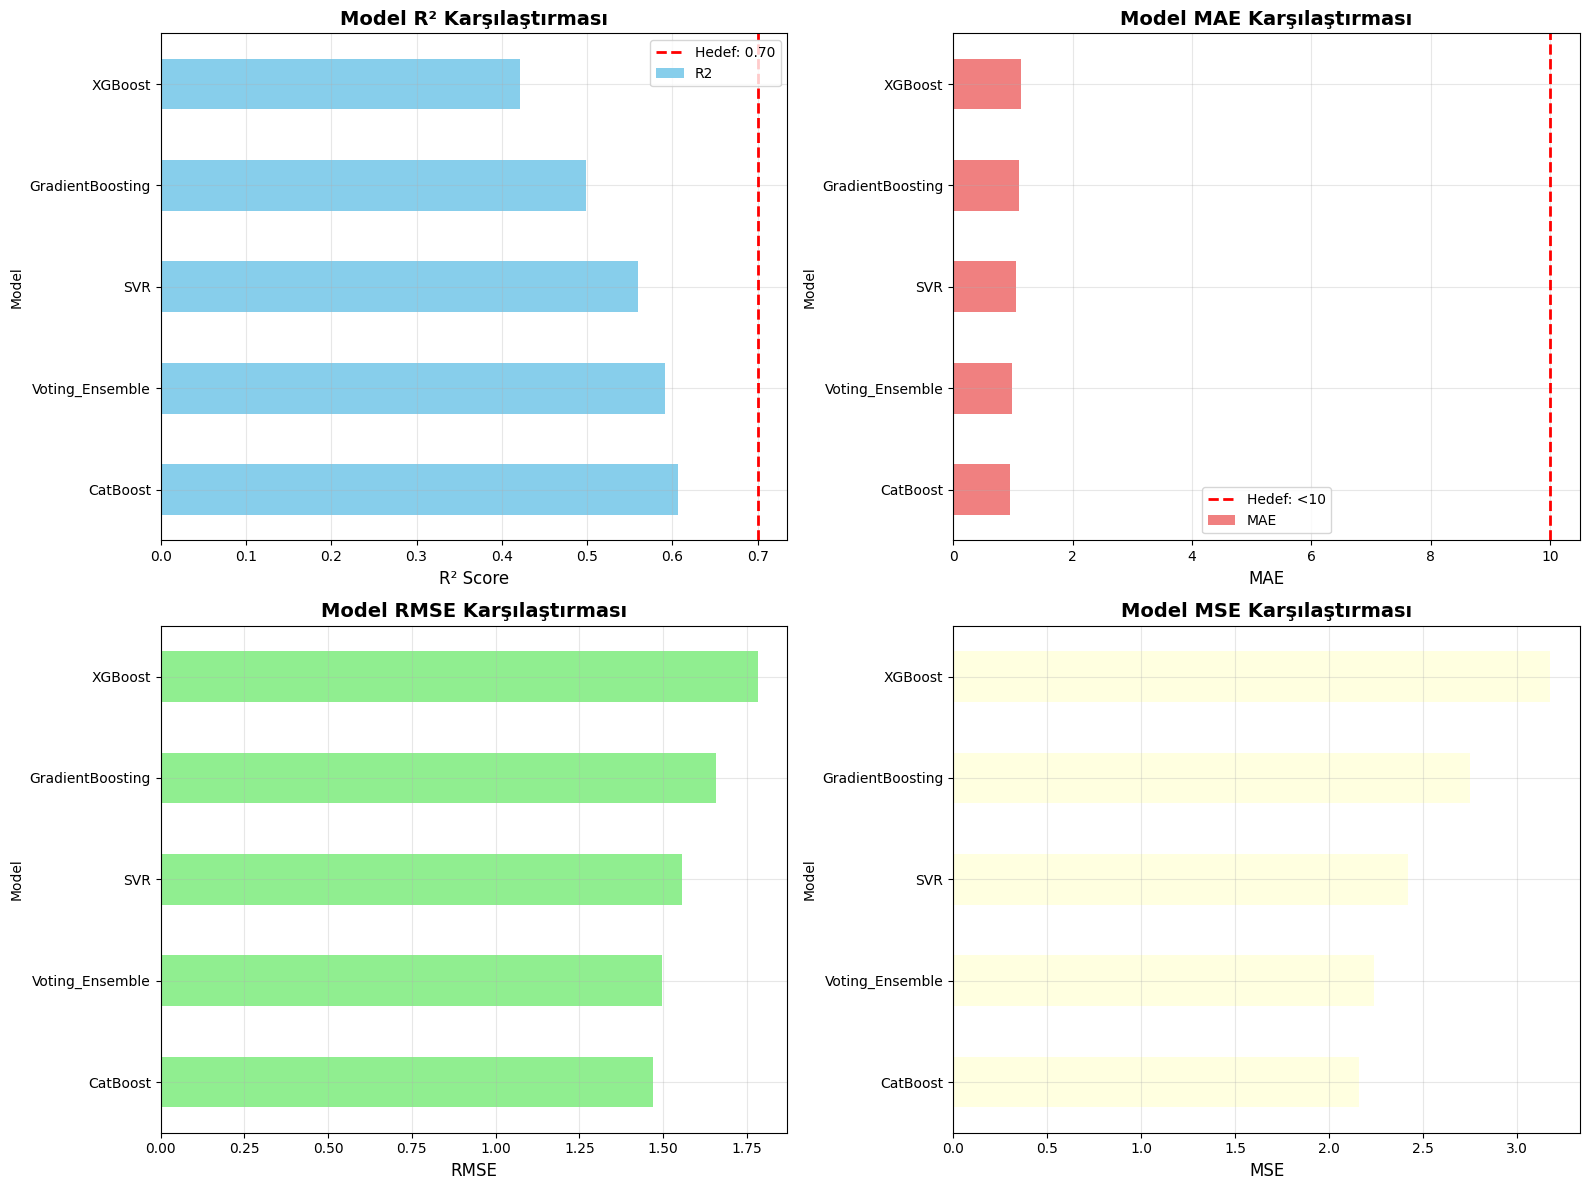

In [ ]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('R2', ascending=False)
print("\n TÜM MODELLER:")
display(df_results)
best_model = df_results.iloc[0]
print(f"\n EN İYİ MODEL: {best_model['Model']}")
print(f"   R² Score: {best_model['R2']:.4f}")
print(f"   MAE: {best_model['MAE']:.4f}")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
df_results.plot(x='Model', y='R2', kind='barh', ax=ax1, color='skyblue', legend=False)
ax1.set_xlabel('R² Score', fontsize=12)
ax1.set_title('Model R² Karşılaştırması', fontsize=14, fontweight='bold')
ax1.axvline(x=0.70, color='r', linestyle='--', linewidth=2, label='Hedef: 0.70')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[0, 1]
df_results.plot(x='Model', y='MAE', kind='barh', ax=ax2, color='lightcoral', legend=False)
ax2.set_xlabel('MAE', fontsize=12)
ax2.set_title('Model MAE Karşılaştırması', fontsize=14, fontweight='bold')
ax2.axvline(x=10, color='r', linestyle='--', linewidth=2, label='Hedef: <10')
ax2.legend()
ax2.grid(alpha=0.3)

ax3 = axes[1, 0]
df_results.plot(x='Model', y='RMSE', kind='barh', ax=ax3, color='lightgreen', legend=False)
ax3.set_xlabel('RMSE', fontsize=12)
ax3.set_title('Model RMSE Karşılaştırması', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
df_results.plot(x='Model', y='MSE', kind='barh', ax=ax4, color='lightyellow', legend=False)
ax4.set_xlabel('MSE', fontsize=12)
ax4.set_title('Model MSE Karşılaştırması', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "random_state": 42,
        "n_jobs": -1
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    return mae

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\n En iyi MAE: {study.best_value:.4f}")
print(f" En iyi parametreler:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

print("\n En iyi parametrelerle XGBoost yeniden eğitiliyor")
xgb_optimized = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
xgb_optimized.fit(X_train, y_train)
y_pred_opt = xgb_optimized.predict(X_test)

mae_opt = mean_absolute_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)

print(f"  Optimized MAE: {mae_opt:.4f}")
print(f"  Optimized R²:  {r2_opt:.4f}")

[I 2026-02-19 13:29:07,966] A new study created in memory with name: no-name-96b91edf-8d3c-44c5-b50c-8686e9254815


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-02-19 13:29:33,838] Trial 0 finished with value: 1.172554969129234 and parameters: {'n_estimators': 442, 'max_depth': 8, 'learning_rate': 0.043336576891045635, 'subsample': 0.7757422011540669, 'colsample_bytree': 0.6419198530205091, 'gamma': 2.7399331045563375}. Best is trial 0 with value: 1.172554969129234.
[I 2026-02-19 13:30:28,454] Trial 1 finished with value: 1.1010094180240282 and parameters: {'n_estimators': 550, 'max_depth': 12, 'learning_rate': 0.017675532771358037, 'subsample': 0.6853921061062795, 'colsample_bytree': 0.8441766545604574, 'gamma': 1.614477487872787}. Best is trial 1 with value: 1.1010094180240282.
[I 2026-02-19 13:30:32,649] Trial 2 finished with value: 1.166860571926511 and parameters: {'n_estimators': 395, 'max_depth': 4, 'learning_rate': 0.17453741108504753, 'subsample': 0.7453611396904246, 'colsample_bytree': 0.7007890485433579, 'gamma': 3.0531387085799633}. Best is trial 1 with value: 1.1010094180240282.
[I 2026-02-19 13:30:43,624] Trial 3 finished